# NISAR DEM (v1.2): Access and Visualize

**Date:** March 4, 2026

**Author:** Harshini Girish(UAH), Alex Mandel(Development Seed), Chuck Daniels(Development Seed), Samantha Niemoeller(JPL)

**Description:** This notebook subsets a small Area of Interest (AOI) from the NISAR DEM VRT stored in ASF’s S3 bucket using GDAL/rasterio’s S3 virtual filesystem (/vsis3/). It authenticates via Earthdata to fetch temporary S3 credentials, configures the required AWS/GDAL environment variables, writes the AOI subset to a local GeoTIFF, and then renders a quick image preview of the output.

## Run This Notebook

To access and run this tutorial within MAAP's Algorithm Development Environment (ADE), please refer to the ["Getting started with the MAAP"](https://docs.maap-project.org/en/latest/getting_started/getting_started.html) section of our documentation.

Disclaimer: it is highly recommended to run a tutorial within MAAP's ADE, which already includes packages specific to MAAP, such as maap-py. Running the tutorial outside of the MAAP ADE may lead to errors. Additionally, it is recommended to use the `Pangeo` workspace within the ADE, since certain packages relevant to this tutorial are already installed.

## About the Data

This notebook uses the **NISAR DEM v1.2** collection hosted by the **NASA Alaska Satellite Facility (ASF) DAAC**. It is a **global digital elevation model (DEM)** prepared for NISAR processing workflows and is **not derived from NISAR measurements**; instead, it is **modified from the Copernicus DEM 30 m** source product. Key modifications include converting the vertical reference from the **EGM2008 geoid to the WGS84 ellipsoid**, filling gaps (e.g., over ocean / missing tiles) to provide **complete global coverage**, and publishing the data through a **hierarchical VRT (Virtual Raster) structure** for fast, unified access. The top-level VRT file (**`EPSG4326.vrt`**) points to a second tier of VRTs organized by latitude bands, which in turn reference the underlying tiles; this makes it easy to access the DEM as one “virtual mosaic” without manually managing tile lists. Note: because elevations are ellipsoid-referenced, this dataset should **not** be used for applications that specifically require **geoid-based elevations**.

## Additional Resources

- [NISAR Access](https://docs.maap-project.org/en/latest/science/NISAR/NISAR_access.html)
- [Searching NISAR + BIOMASS Overlapping Data](https://docs.maap-project.org/en/develop/technical_tutorials/search/searching_NISAR_BIOMASS_overlapping_data.html)

## Imports

Load all required libraries (rasterio/GDAL for raster I/O, earthaccess for authentication, and matplotlib for a quick preview).

In [1]:
import os
import time
from pathlib import Path
import numpy as np
import rasterio
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt

import earthaccess

## Parameters

Define the DEM version/projection directory and the AOI bounding box to subset.

In [2]:
# --- DEM version + projection directory ---
DEM_VERSION = "v1.2"
EPSG_DIR = "EPSG4326"  # also available: "EPSG3413" (Arctic), "EPSG3031" (Antarctic)

# --- AOI bbox ---
# For EPSG4326: lon/lat bbox (min_lon, min_lat, max_lon, max_lat)
BBOX = (-116.7, 35.9, -116.6, 36.0)

## VRT paths

Construct the VRT path in ASF’s S3 bucket. The /vsis3/ path is what rasterio/GDAL will read directly from S3.

In [3]:
# --- ASF S3 VRT (DEM mosaic as a VRT) ---
ASF_S3_BUCKET = "sds-n-cumulus-prod-nisar-products"
S3_KEY = f"DEM/{DEM_VERSION}/{EPSG_DIR}/{EPSG_DIR}.vrt"

S3_VRT_S3URI = f"s3://{ASF_S3_BUCKET}/{S3_KEY}"
S3_VRT_VSI = f"/vsis3/{ASF_S3_BUCKET}/{S3_KEY}"

S3_VRT_S3URI

's3://sds-n-cumulus-prod-nisar-products/DEM/v1.2/EPSG4326/EPSG4326.vrt'

## Set up Access

Log in via Earthdata and request short-lived S3 credentials from ASF so the S3 VRT can be accessed.

In [5]:
#Fetch temporary S3 credentials via Earthdata login
ASF_S3CREDS_ENDPOINT = "https://nisar.asf.earthdatacloud.nasa.gov/s3credentials"

auth = earthaccess.login()

creds = None
for attempt in range(1, 6):
    try:
        creds = auth.get_s3_credentials(endpoint=ASF_S3CREDS_ENDPOINT)
        print(f"Got S3 creds on attempt {attempt}")
        break
    except Exception as e:
        print(f"Attempt {attempt} failed:", type(e).__name__, e)
        time.sleep(5)

if creds is None:
    raise RuntimeError("Could not obtain ASF S3 credentials after retries.")

Got S3 creds on attempt 1


## Environment setup

Export the temporary AWS credentials and request-payer settings as environment variables for /vsis3/ access.

In [7]:
# --- Configure AWS + GDAL request-payer environment for /vsis3/ access ---
os.environ.update(
    {
        "AWS_ACCESS_KEY_ID": creds["accessKeyId"],
        "AWS_SECRET_ACCESS_KEY": creds["secretAccessKey"],
        "AWS_SESSION_TOKEN": creds["sessionToken"],
        "AWS_REGION": "us-west-2",
        "AWS_DEFAULT_REGION": "us-west-2",
        "AWS_REQUEST_PAYER": "requester",
        "CPL_AWS_REQUEST_PAYER": "requester",
    }
)


## Subsetting helper

Define a helper function that computes a raster window for the AOI bounding box and writes the subset to a local GeoTIFF.

In [6]:
def subset_to_geotiff(dataset_path: str, bbox, out_tif: str):
    """Read a window from a raster dataset and write it to a local GeoTIFF."""
    minx, miny, maxx, maxy = bbox

    with rasterio.open(dataset_path) as src:
        win = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
        data = src.read(1, window=win)
        new_transform = src.window_transform(win)

        profile = src.profile.copy()
        profile.update(
            driver="GTiff",
            height=data.shape[0],
            width=data.shape[1],
            transform=new_transform,
            count=1,
        )

    with rasterio.open(out_tif, "w", **profile) as dst:
        dst.write(data, 1)

## Run subset

Execute the subset against the S3 VRT and write the resulting AOI GeoTIFF locally.

In [11]:
out_s3 = "dem_subset_s3.tif"

try:
    subset_to_geotiff(S3_VRT_VSI, BBOX, out_s3)
    print("S3 subset wrote:", out_s3)
except Exception as e:
    print("S3 subset failed:", type(e).__name__, e)
    raise

S3 subset wrote: dem_subset_s3.tif


## Preview

Open the output GeoTIFF, convert nodata to NaN, and render a quick image preview.

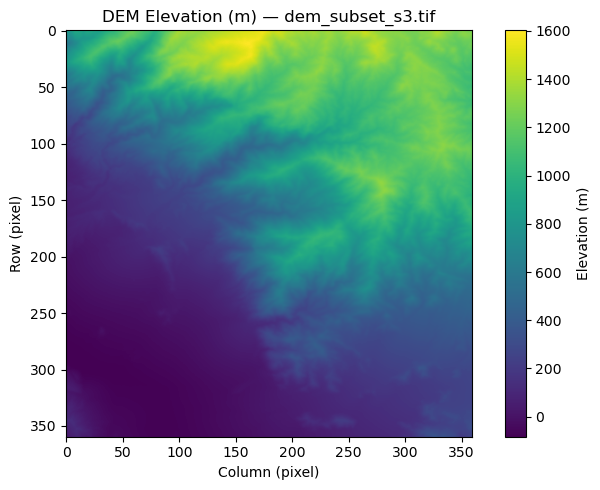

In [12]:
# plot DEM elevation array (pixel coordinates) with labels

if Path(out_s3).exists():
    with rasterio.open(out_s3) as src:
        arr = src.read(1)          # arr: DEM elevation values (band 1)
        nodata = src.nodata        # nodata: nodata sentinel value (if defined)

    # Convert nodata pixels to NaN so they don't affect display
    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr)

    plt.figure(figsize=(7, 5))
    im = plt.imshow(arr)  # X: column (pixel), Y: row (pixel), color: elevation value
    plt.title(f"DEM Elevation (m) — {Path(out_s3).name}")
    plt.xlabel("Column (pixel)")
    plt.ylabel("Row (pixel)")

    cbar = plt.colorbar(im)
    cbar.set_label("Elevation (m)")

    plt.tight_layout()
    plt.show()
else:
    print(f"File not found: {out_s3}")